In [1]:
!pwd

/home/gusloryst@GU.GU.SE/mgr/image_processing


In [2]:
import PhotoBook.logsProcessing_export

Loading logs from logs...
0 files found.
DONE. Loaded 0 completed game logs.


In [3]:
import torch
# device = 'cuda:3'
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Using device:", device)

In [4]:
from PIL import Image
from llava.model.builder import load_pretrained_model
from llava.mm_utils import process_images, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from matplotlib import pyplot as plt

[2026-05-09 13:57:02,819] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)


2026-05-09 13:57:23.238993: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-09 13:57:23.304285: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 13:57:45.663861: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
model_path = "liuhaotian/llava-v1.5-7b"

tokenizer, model, image_processor, context_len = load_pretrained_model(model_path, None, model_name="llava_v1_5", device_map="auto", torch_dtype=torch.float16)
# model = model.to(device)

/home/gusloryst@GU.GU.SE/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/home/gusloryst@GU.GU.SE/.local/lib/python3.8/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [6]:
print(next(model.parameters()).device)

cuda:0


In [7]:
# def merge2images(img_path1, img_path2, out_path, line_width=5, line_color=(0, 0, 0)):

#     im1 = Image.open(img_path1)
#     im2 = Image.open(img_path2)

#     min_h = min(im1.height, im2.height)
#     im1 = im1.resize((int(im1.width * min_h / im1.height), min_h))
#     im2 = im2.resize((int(im2.width * min_h / im2.height), min_h))

#     new_w = im1.width + line_width + im2.width
#     new_h = min_h
#     canvas = Image.new("RGB", (new_w, new_h), (255, 255, 255))

#     canvas.paste(im1, (0, 0))

#     line_img = Image.new("RGB", (line_width, new_h), (0,0,0))
#     canvas.paste(line_img, (im1.width, 0))

#     canvas.paste(im2, (im1.width + line_width, 0))

#     canvas.save(out_path)

# merge2images("../../cats_in_love.jpg", "../../example.jpg", "PhotoBook/merged_images/example_merge.jpg")


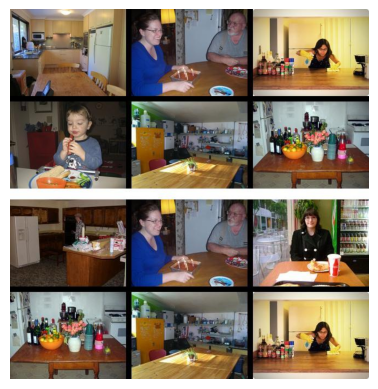

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 2 has a total capacty of 10.90 GiB of which 19.31 MiB is free. Process 3377682 has 9.42 GiB memory in use. Including non-PyTorch memory, this process has 1.46 GiB memory in use. Of the allocated memory 1.32 GiB is allocated by PyTorch, and 1.75 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [8]:
example = Image.open("PhotoBook/merged_images/2106_2_merged.jpg")

plt.imshow(example)
plt.axis('off')
plt.show()

image_tensor = process_images([example], image_processor, model.config)
image_tensor = image_tensor.to(model.device, dtype=torch.float16)

# prompt = DEFAULT_IMAGE_TOKEN + "\nUSER: <image>\nWhat is in this image?\nASSISTANT:"
prompt = "USER: <image>\nYou are given a photobook spread. The top half shows one page and the bottom half shows another page, separated by a white stripe.\nEach page contains 6 photos.\nTask:\n1. Compare the two pages.\n2. Count how many photos appear on both pages (the same or very similar).\n3. Describe the matching photos.\nAnswer clearly and step by step.\nASSISTANT:"

# "\n<image>\nYou are playing a game. You are given two pages from photobook. Each page contains 6 images. First page is in the top and second in the bottom, they are devided by white stripe. Tell me how many photos are the same in both pages. Describe them to me"
# "\n<image>\nDescribe this collage. How many images are there? Decribe each image from the collage"


input_ids = tokenizer_image_token(
    prompt,
    tokenizer,
    IMAGE_TOKEN_INDEX,
    return_tensors="pt"
).unsqueeze(0).to(model.device)

output_ids = model.generate(
    input_ids,
    images=image_tensor,
    max_new_tokens=10000
)

print(tokenizer.decode(output_ids[0], skip_special_tokens=False))

In [ ]:
#######

In [ ]:
%store -r round_list_tpl